In [1]:
#4.1 and 4.2
#Multiple Linear Regression

import pandas as pd 
import statsmodels.api as sm

#Fetch and load data set
student_ID = '40443014'
data_set = pd.read_csv(f"{student_ID}_features.csv")

#Height and Width for prediction of Aspect ratio
X = data_set[['height', 'width']]
y = data_set['aspect_ratio']

#Constant to calculate y-intercept
X = sm.add_constant(X)

#Fit OLS Linear Regression model
model = sm.OLS(y,X).fit()

results = {
    'Metric' : [
        'R-squared',
        'Adjusted R-squared',
        'Mean Squared Error',
        'Intercept',
        'Coefficient Height',
        'Coefficient Width'

    ],
    'Value': [
        f"{model.rsquared:.4f}",
        f"{model.rsquared_adj:.4f}",
        f"{model.mse_resid:.4f}",
        f"{model.params['const']:.4f}",
        f"{model.params['height']:.4f}",
        f"{model.params['width']:.4f}"

    ]
}

#Convert to DataFrame
results_table = pd.DataFrame(results)

print("Regression Model Assessment")
print(results_table.to_string(index=False))

#Parameters used for model equation
intercept = model.params['const']
coef_height = model.params['height']
coef_width = model.params['width']

print("\nModel Equation")
print(f"Aspect Ratio = {intercept:.4f} + ({coef_height:.4f} * height) + ({coef_width:.4f} * width)")


Regression Model Assessment
            Metric   Value
         R-squared  0.9743
Adjusted R-squared  0.9738
Mean Squared Error  0.0028
         Intercept  1.4287
Coefficient Height -0.0477
 Coefficient Width  0.0339

Model Equation
Aspect Ratio = 1.4287 + (-0.0477 * height) + (0.0339 * width)


<h1> Multiple Linear Regression Model Code Breakdown</h1>

1. Libraries are imported and the dataset is fetched and loaded.

2. Matrix containing features 'height' and 'width' (will be the parsimonious subset) is created and stored in 'X'. The target, 'aspect_ratio' (feature that code is trying to predict), is stored in 'y'.

3. A constant column is added to the 'X' matrix to allow the algorithm to properly calculate the y-intercept.

4. 'X' is mapped to 'y' and the Ordinary Least Squares (OLS) algorithm is applied. The resulting trained model is then saved in variable 'model'.

5. In 'results' dictionary, the specific evaluation metrics extracted from OLS model are matched to their respective labels.

6. 'results' is passed into DataFrame(), converted into a pandas table and printed.

7. Variables 'intercept', 'coef_height' and 'coef_width' all extract the specific parameters from 'model'. The results are plugged into a readable equation to show how the model predicts aspect ratio.

Coefficients: [[-0.23988475]], Intercept: [2.56106713]


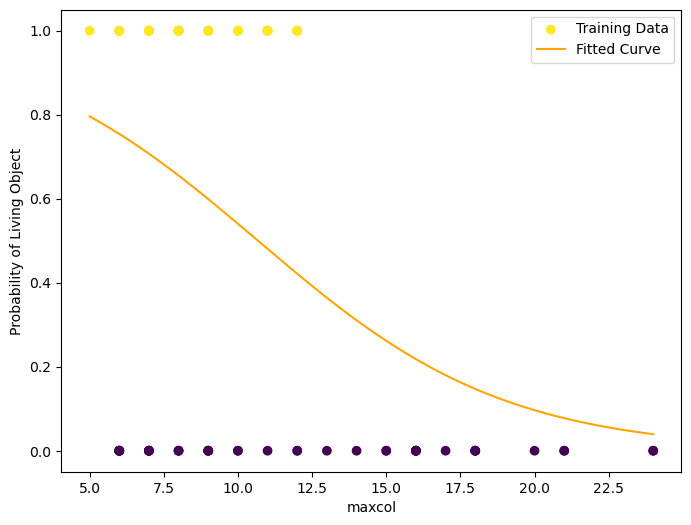

Training Accuracy: 0.6292134831460674
Testing Accuracy: 0.5652173913043478


In [2]:
#4.3
#Logistic Regression Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#Fetch and load data set
student_ID = '40443014'
data_set = pd.read_csv(f"{student_ID}_features.csv")

#Dummy variable for living objects
living_objects = ['banana', 'cherry', 'tree', 'lemon']
data_set['dummy_living'] = np.where(data_set['Object'].isin(living_objects), 1, 0)

#Shuffle and split data into training and testing sets (80/20 split)
data_set=data_set.sample(frac=1, random_state=42).reset_index(drop=True)
split_index = int(len(data_set) * 0.8)
train_data = data_set[:split_index]
test_data = data_set[split_index:]

#Logistic regression with maxcol
X_train = train_data[['maxcol']].values
y_train = train_data['dummy_living'].values

model = LogisticRegression()
model.fit(X_train, y_train)

#Display coefficient
print(f"Coefficients: {model.coef_}, Intercept: {model.intercept_}")

#Plot fitted Logistic regression curve
x_vals = np.linspace(train_data['maxcol'].min(), train_data['maxcol'].max(), 1000)
fitted_curve = model.predict_proba(x_vals.reshape(-1, 1))[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(train_data['maxcol'], train_data['dummy_living'], c=train_data['dummy_living'], cmap='viridis', label='Training Data')
plt.plot(x_vals, fitted_curve, color='orange', label='Fitted Curve')
plt.xlabel('maxcol')
plt.ylabel('Probability of Living Object')
plt.legend()
plt.show()

#Calculate training accuracy
train_preds = (model.predict_proba(X_train)[:, 1] > 0.5).astype(int)
train_accuracy = accuracy_score(y_train, train_preds)
print(f"Training Accuracy: {train_accuracy}")

#Calculate testing accuracy
X_test = test_data[['maxcol']].values
y_test = test_data['dummy_living'].values

test_preds = (model.predict_proba(X_test)[:, 1] > 0.5).astype(int)
test_accuracy = accuracy_score(y_test, test_preds)
print(f"Testing Accuracy: {test_accuracy}")

<h1> 4.3 Code Breakdown</h1>

1. Libraries are imported and the dataset is fetched and loaded.

2. Define living objects and create a target column that assigns a living object a 1 and non-living a 0 (allows algorithm to analyze data).

3. The dataset is randomly shuffled then split into two groups. 80% of the dataset is split into training set and the remaining 20% is in the test set.

4. 'X_train' isolates the predictor feature ('maxcol') and 'y_train' isolates the target variable (dummy_living). These are isolated for the model training.

5. An instance of the Logistic Regression classifier is created and the '.fit()' method is called using 'X_train' and 'y_train' to calculate the optimal coefficients. These coefficients are then used to map 'maxcol' to the probability of an object being living. Results are then printed.

6. A continuous range of 1000 evenly spaced points is created, which the model uses to predict probabilities to draw the sigmoid curve.

7. Plot is created and printed (visually adapted from "141_logistic_regression_iris code" example provided in Canvas).

8. 'train_preds' uses the training set and sets a 50% threshold. If the model calculates a probability higher than 0.5 it predicts living and any lower than 0.5 predicts non-living. Accuracy is then calculated by comparing predictions with actual data labels. Result is then printed.

9. 'test_preds' repeats the above step but using the smaller test set.